In [1]:
# Importing Libraries
from __future__ import print_function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Manasi\NMIMS\Manasi\Capstone Project\Agriculture\Bhoomi\data\crop_recommendation.csv")

In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [5]:
df.size

17600

In [6]:
df.shape

(2200, 8)

In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [8]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [9]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [10]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

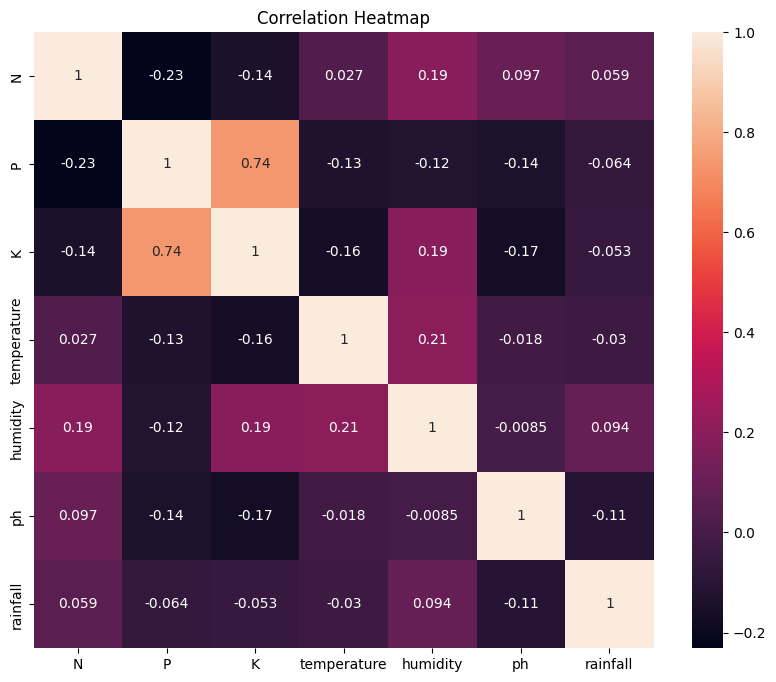

In [11]:
# Visualizing Correlation Heatmap for Numeric Columns Only
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


### Seperating features and target label

In [12]:
# Separating Features and Target Variable
features = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
target = df['label']

In [13]:
# Initializing Lists to Store Accuracy Scores and Model Names
acc = []
model = []

In [14]:
# Splitting the Dataset into Train and Test Sets
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features, target, test_size=0.2, random_state=2)

In [15]:
# Label Encoding the Target Variable
label_encoder = LabelEncoder()
Ytrain_encoded = label_encoder.fit_transform(Ytrain)
Ytest_encoded = label_encoder.transform(Ytest)

# Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [17]:
DecisionTree = DecisionTreeClassifier(criterion="entropy", random_state=2, max_depth=5)
DecisionTree.fit(Xtrain, Ytrain)
predicted_values = DecisionTree.predict(Xtest)

In [18]:
x = accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("\nDecision Tree's Accuracy:", x * 100)
print(classification_report(Ytest, predicted_values))


Decision Tree's Accuracy: 90.0
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.59      1.00      0.74        16
    chickpea       1.00      1.00      1.00        21
     coconut       0.91      1.00      0.95        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.74      0.93      0.83        28
 kidneybeans       0.00      0.00      0.00        14
      lentil       0.68      1.00      0.81        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       0.00      0.00      0.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00      

In [19]:
# Cross Validation Score for Decision Tree
cv_score = cross_val_score(DecisionTree, features, target, cv=5)
print("Cross Validation Score (Decision Tree):", cv_score)

Cross Validation Score (Decision Tree): [0.93636364 0.90909091 0.91818182 0.87045455 0.93636364]


In [20]:
# Saving the Decision Tree Model
with open("decision_tree_model_crop_recommendation.pkl", "wb") as file:
    pickle.dump(DecisionTree, file)

# Guassian Naive Bayes

In [21]:
from sklearn.naive_bayes import GaussianNB

In [22]:
NaiveBayes = GaussianNB()
NaiveBayes.fit(Xtrain, Ytrain)
predicted_values = NaiveBayes.predict(Xtest)

In [23]:
x = accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("\nNaive Bayes's Accuracy:", x*100)
print(classification_report(Ytest, predicted_values))


Naive Bayes's Accuracy: 99.0909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.88      1.00      0.93        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      1.00      1.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      

In [24]:
# Cross Validation Score for Naive Bayes
cv_score = cross_val_score(NaiveBayes, features, target, cv=5)
print("Cross Validation Score (Naive Bayes):", cv_score)

Cross Validation Score (Naive Bayes): [0.99772727 0.99545455 0.99545455 0.99545455 0.99090909]


In [25]:
# Saving the Naive Bayes Model
with open("gnb_model_crop_recommendation.pkl", "wb") as file:
    pickle.dump(NaiveBayes, file)

# Support Vector Machine (SVM)

In [26]:
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler

In [27]:
scaler = MinMaxScaler().fit(Xtrain)
X_train_norm = scaler.transform(Xtrain)
X_test_norm = scaler.transform(Xtest)

In [28]:
SVM = SVC(kernel='poly', degree=3, C=1)
SVM.fit(X_train_norm, Ytrain)
predicted_values = SVM.predict(X_test_norm)

In [29]:
x = accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('SVM')
print("\nSVM's Accuracy:", x*100)
print(classification_report(Ytest, predicted_values))


SVM's Accuracy: 97.95454545454545
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      0.95      0.98        22
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        18
        jute       0.83      0.89      0.86        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      1.00      1.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00   

In [30]:
# Cross Validation Score for SVM
cv_score = cross_val_score(SVM, features, target, cv=5)
print("Cross Validation Score (SVM):", cv_score)

Cross Validation Score (SVM): [0.97954545 0.975      0.98863636 0.98863636 0.98181818]


In [31]:
# Saving the SVM Model
with open("svm_model_crop_recommendation.pkl", "wb") as file:
    pickle.dump(SVM, file)

# Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
LogReg = LogisticRegression(random_state=2)
LogReg.fit(Xtrain, Ytrain)
predicted_values = LogReg.predict(Xtest)

In [34]:
x = accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Logistic Regression')
print("\nLogistic Regression's Accuracy:", x*100)
print(classification_report(Ytest, predicted_values))


Logistic Regression's Accuracy: 95.22727272727273
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.86      0.75      0.80        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       0.86      0.90      0.88        20
      grapes       1.00      1.00      1.00        18
        jute       0.84      0.93      0.88        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.88      1.00      0.94        23
       maize       0.90      0.86      0.88        21
       mango       0.96      1.00      0.98        26
   mothbeans       0.84      0.84      0.84        19
    mungbean       1.00      0.96      0.98        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1

In [35]:
# Cross Validation Score for Logistic Regression
cv_score = cross_val_score(LogReg, features, target, cv=5)
print("Cross Validation Score (Logistic Regression):", cv_score)

Cross Validation Score (Logistic Regression): [0.95       0.96590909 0.94772727 0.96590909 0.94318182]


In [36]:
# Saving the Logistic Regression Model
with open("lr_model_crop_recommendation.pkl", "wb") as file:
    pickle.dump(LogReg, file)

# Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(Xtrain, Ytrain)
predicted_values = RF.predict(Xtest)

In [39]:
x = accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Random Forest')
print("\nRandom Forest's Accuracy:", x)
print(classification_report(Ytest, predicted_values))


Random Forest's Accuracy: 0.990909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.94      1.00      0.97        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.90      1.00      0.95        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.95      0.97        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00   

In [40]:
# Cross Validation Score for Random Forest
cv_score = cross_val_score(RF, features, target, cv=5)
print("Cross Validation Score (Random Forest):", cv_score)

Cross Validation Score (Random Forest): [0.99772727 0.99545455 0.99772727 0.99318182 0.98863636]


In [41]:
# Saving the Random Forest Model
with open("rf_model_crop_recommendation.pkl", "wb") as file:
    pickle.dump(RF, file)

# XGBoost

In [42]:
import xgboost as xgb

In [43]:
XB = xgb.XGBClassifier()
XB.fit(Xtrain, Ytrain_encoded)
predicted_values = XB.predict(Xtest)
predicted_labels = label_encoder.inverse_transform(predicted_values)

In [44]:
x = accuracy_score(Ytest, predicted_labels)
acc.append(x)
model.append('XGBoost')
print("\nXGBoost's Accuracy:", x*100)
print(classification_report(Ytest, predicted_labels))


XGBoost's Accuracy: 99.0909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       0.96      1.00      0.98        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.93      0.96      0.95        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      1.00      0.98        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.95      0.97        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00

In [45]:
# Cross Validation Score for XGBoost
cv_score = cross_val_score(XB, features, label_encoder.transform(target), cv=5)
print("Cross Validation Score (XGBoost):", cv_score)

Cross Validation Score (XGBoost): [0.99545455 0.98863636 0.99545455 0.99545455 0.98863636]


In [46]:
# Saving the XGBoost Model
with open("xgboost_model_crop_recommendation.pkl", "wb") as file:
    pickle.dump(XB, file)

## Accuracy Comparison

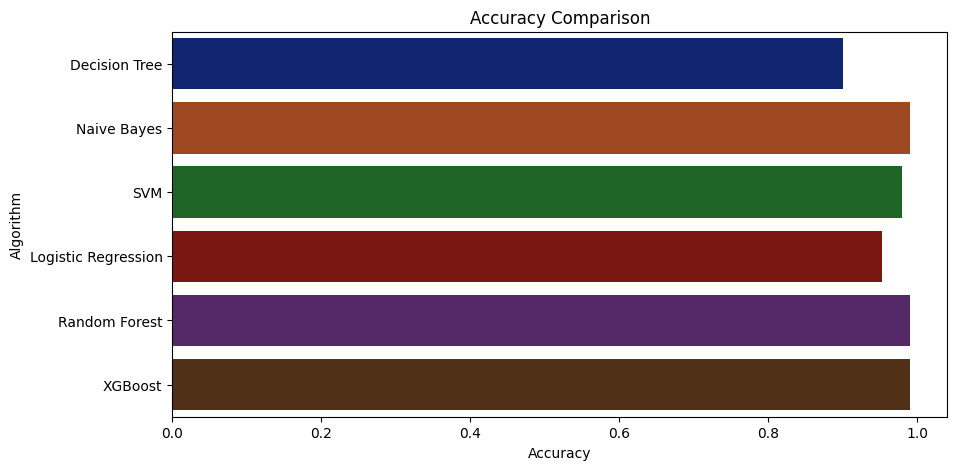

In [47]:
# Accuracy Comparison Plot
plt.figure(figsize=(10, 5))
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x=acc, y=model, palette='dark')
plt.show()

In [48]:
# Displaying the Accuracy of Each Model
accuracy_models = dict(zip(model, acc))
print("\nModel Accuracies:")
for k, v in accuracy_models.items():
    print(f"{k} --> {v:.2f}")


Model Accuracies:
Decision Tree --> 0.90
Naive Bayes --> 0.99
SVM --> 0.98
Logistic Regression --> 0.95
Random Forest --> 0.99
XGBoost --> 0.99


## # Making Predictions with Random Forest Model

In [49]:
data = np.array([[104, 18, 30, 23.603016, 60.3, 6.7, 140.91]])
prediction = RF.predict(data)
print("\nPrediction for sample data 1:", prediction)


Prediction for sample data 1: ['coffee']


In [50]:
data = np.array([[83, 45, 60, 28, 70.3, 7.0, 150.9]])
prediction = RF.predict(data)
print("Prediction for sample data 2:", prediction)

Prediction for sample data 2: ['jute']
